# Check the AMOC time series

In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# For higher resolution images on retina display screens
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

In [3]:
lats = 35 # Choose 26 or 35ºN

## AMOC form msftmz and msftyz

In [4]:
hist_ds = xr.open_mfdataset(f'../outputs/cmip6_amoc/cmip6_msftmz_26N_historical_*.nc')
sce_ds = xr.open_mfdataset(f'../outputs/cmip6_amoc/cmip6_msftmz_26N_ssp245_*.nc')
                           
model_intersection = list(set(hist_ds.model.values) & 
                              set(sce_ds.model.values))
model_intersection.sort()
amoc_ds = xr.concat([hist_ds,sce_ds],'time', join='outer').sel(model=model_intersection)

In [5]:
hist_ds = xr.open_mfdataset(f'../outputs/cmip6_amoc/cmip6_msftyz_26N_historical_*.nc')
sce_ds = xr.open_mfdataset(f'../outputs/cmip6_amoc/cmip6_msftyz_26N_ssp245_*.nc')
                           
model_intersection = list(set(hist_ds.model.values) & 
                              set(sce_ds.model.values))
model_intersection.sort()
amoc_y_ds = xr.concat([hist_ds,sce_ds],'time', join='outer').sel(model=model_intersection)

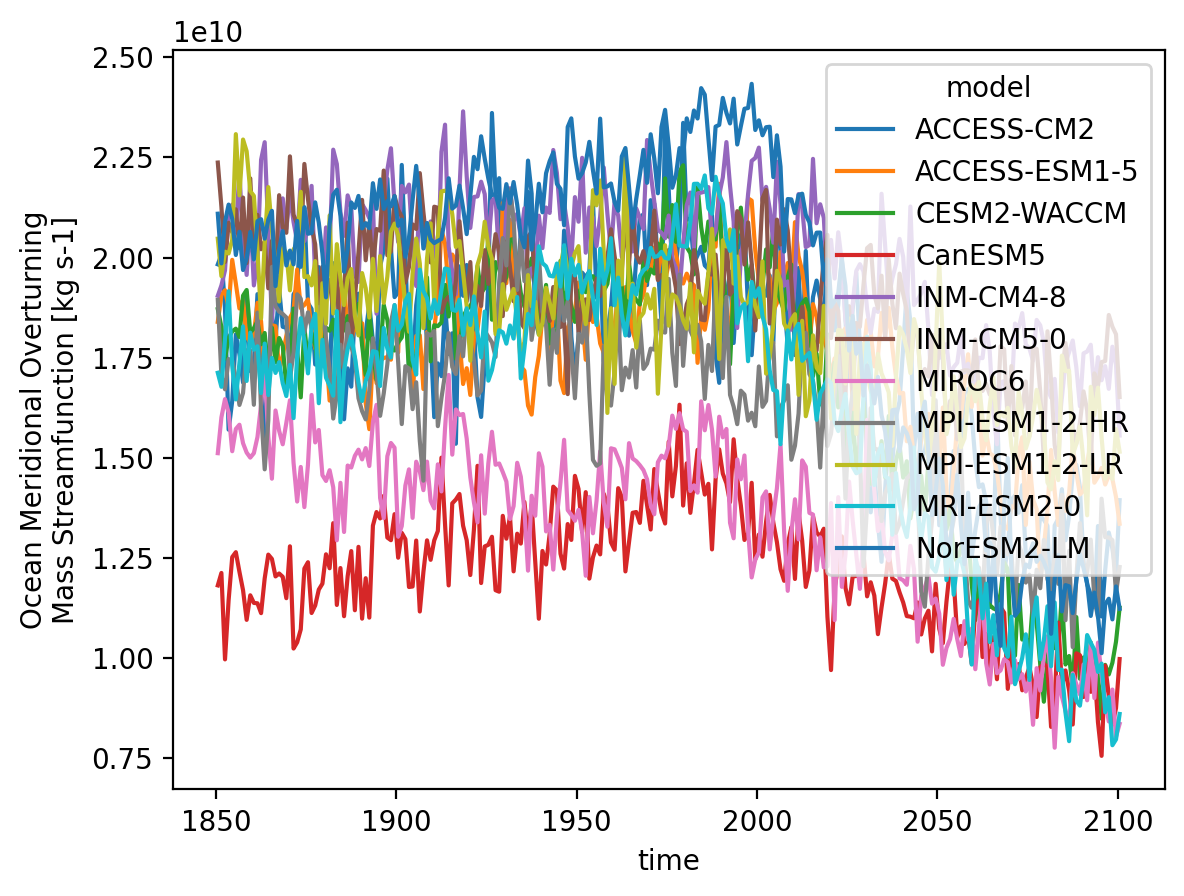

In [6]:
amoc_ds.msftmz.plot.line(x='time');

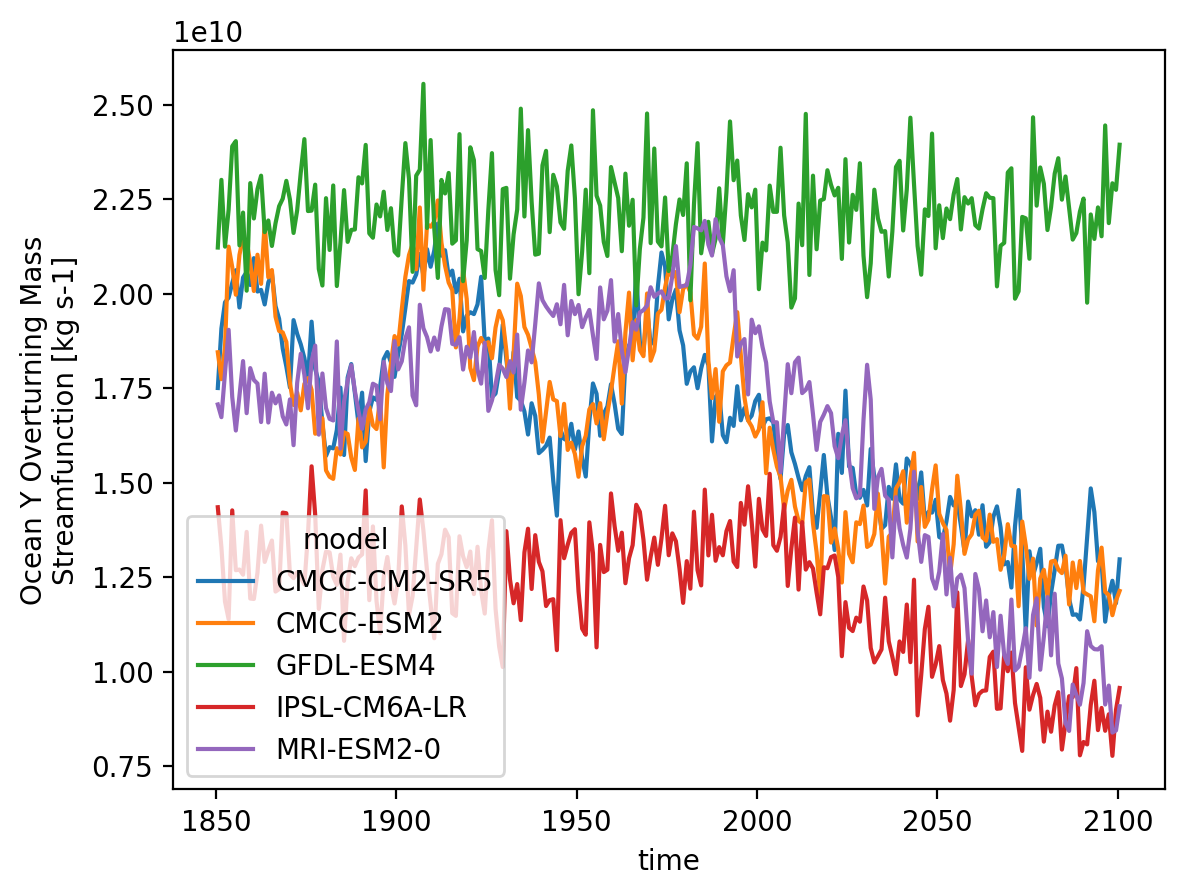

In [7]:
amoc_y_ds.msftyz.plot.line(x='time')

In [8]:
amoc_msftmz_diff = (amoc_ds.msftmz.sel(time=slice(2090.5,2099.5)).mean(dim='time') - 
                    amoc_ds.msftmz.sel(time=slice(1986.5,2005.5)).mean(dim='time'))

rho_0 = 1028 # kg/m3
amoc_msftmz_diff = amoc_msftmz_diff/rho_0/1e6

df_table = pd.DataFrame(amoc_msftmz_diff, index=amoc_msftmz_diff.model)
print(df_table)

                       0
ACCESS-CM2     -6.713229
ACCESS-ESM1-5  -5.078333
CESM2-WACCM    -9.850371
CanESM5        -4.676149
INM-CM4-8      -3.919750
INM-CM5-0      -2.691125
MIROC6         -4.775643
MPI-ESM1-2-HR  -4.395921
MPI-ESM1-2-LR  -3.789514
MRI-ESM2-0     -9.705536
NorESM2-LM    -11.597001


## Look at AMOC computation from meridional velocities

### Check CMIP5 data

In [10]:
cmip5_historical_ds = xr.open_mfdataset('../outputs/cmip5_amoc_vo/*historical*.nc')
cmip5_rcp26_ds = xr.open_mfdataset('../outputs/cmip5_amoc_vo/*rcp26*.nc')
cmip5_rcp45_ds = xr.open_mfdataset('../outputs/cmip5_amoc_vo/*rcp45*.nc')
cmip5_rcp85_ds = xr.open_mfdataset('../outputs/cmip5_amoc_vo/*rcp85*.nc')

Text(0.5, 1.0, 'ssp585')

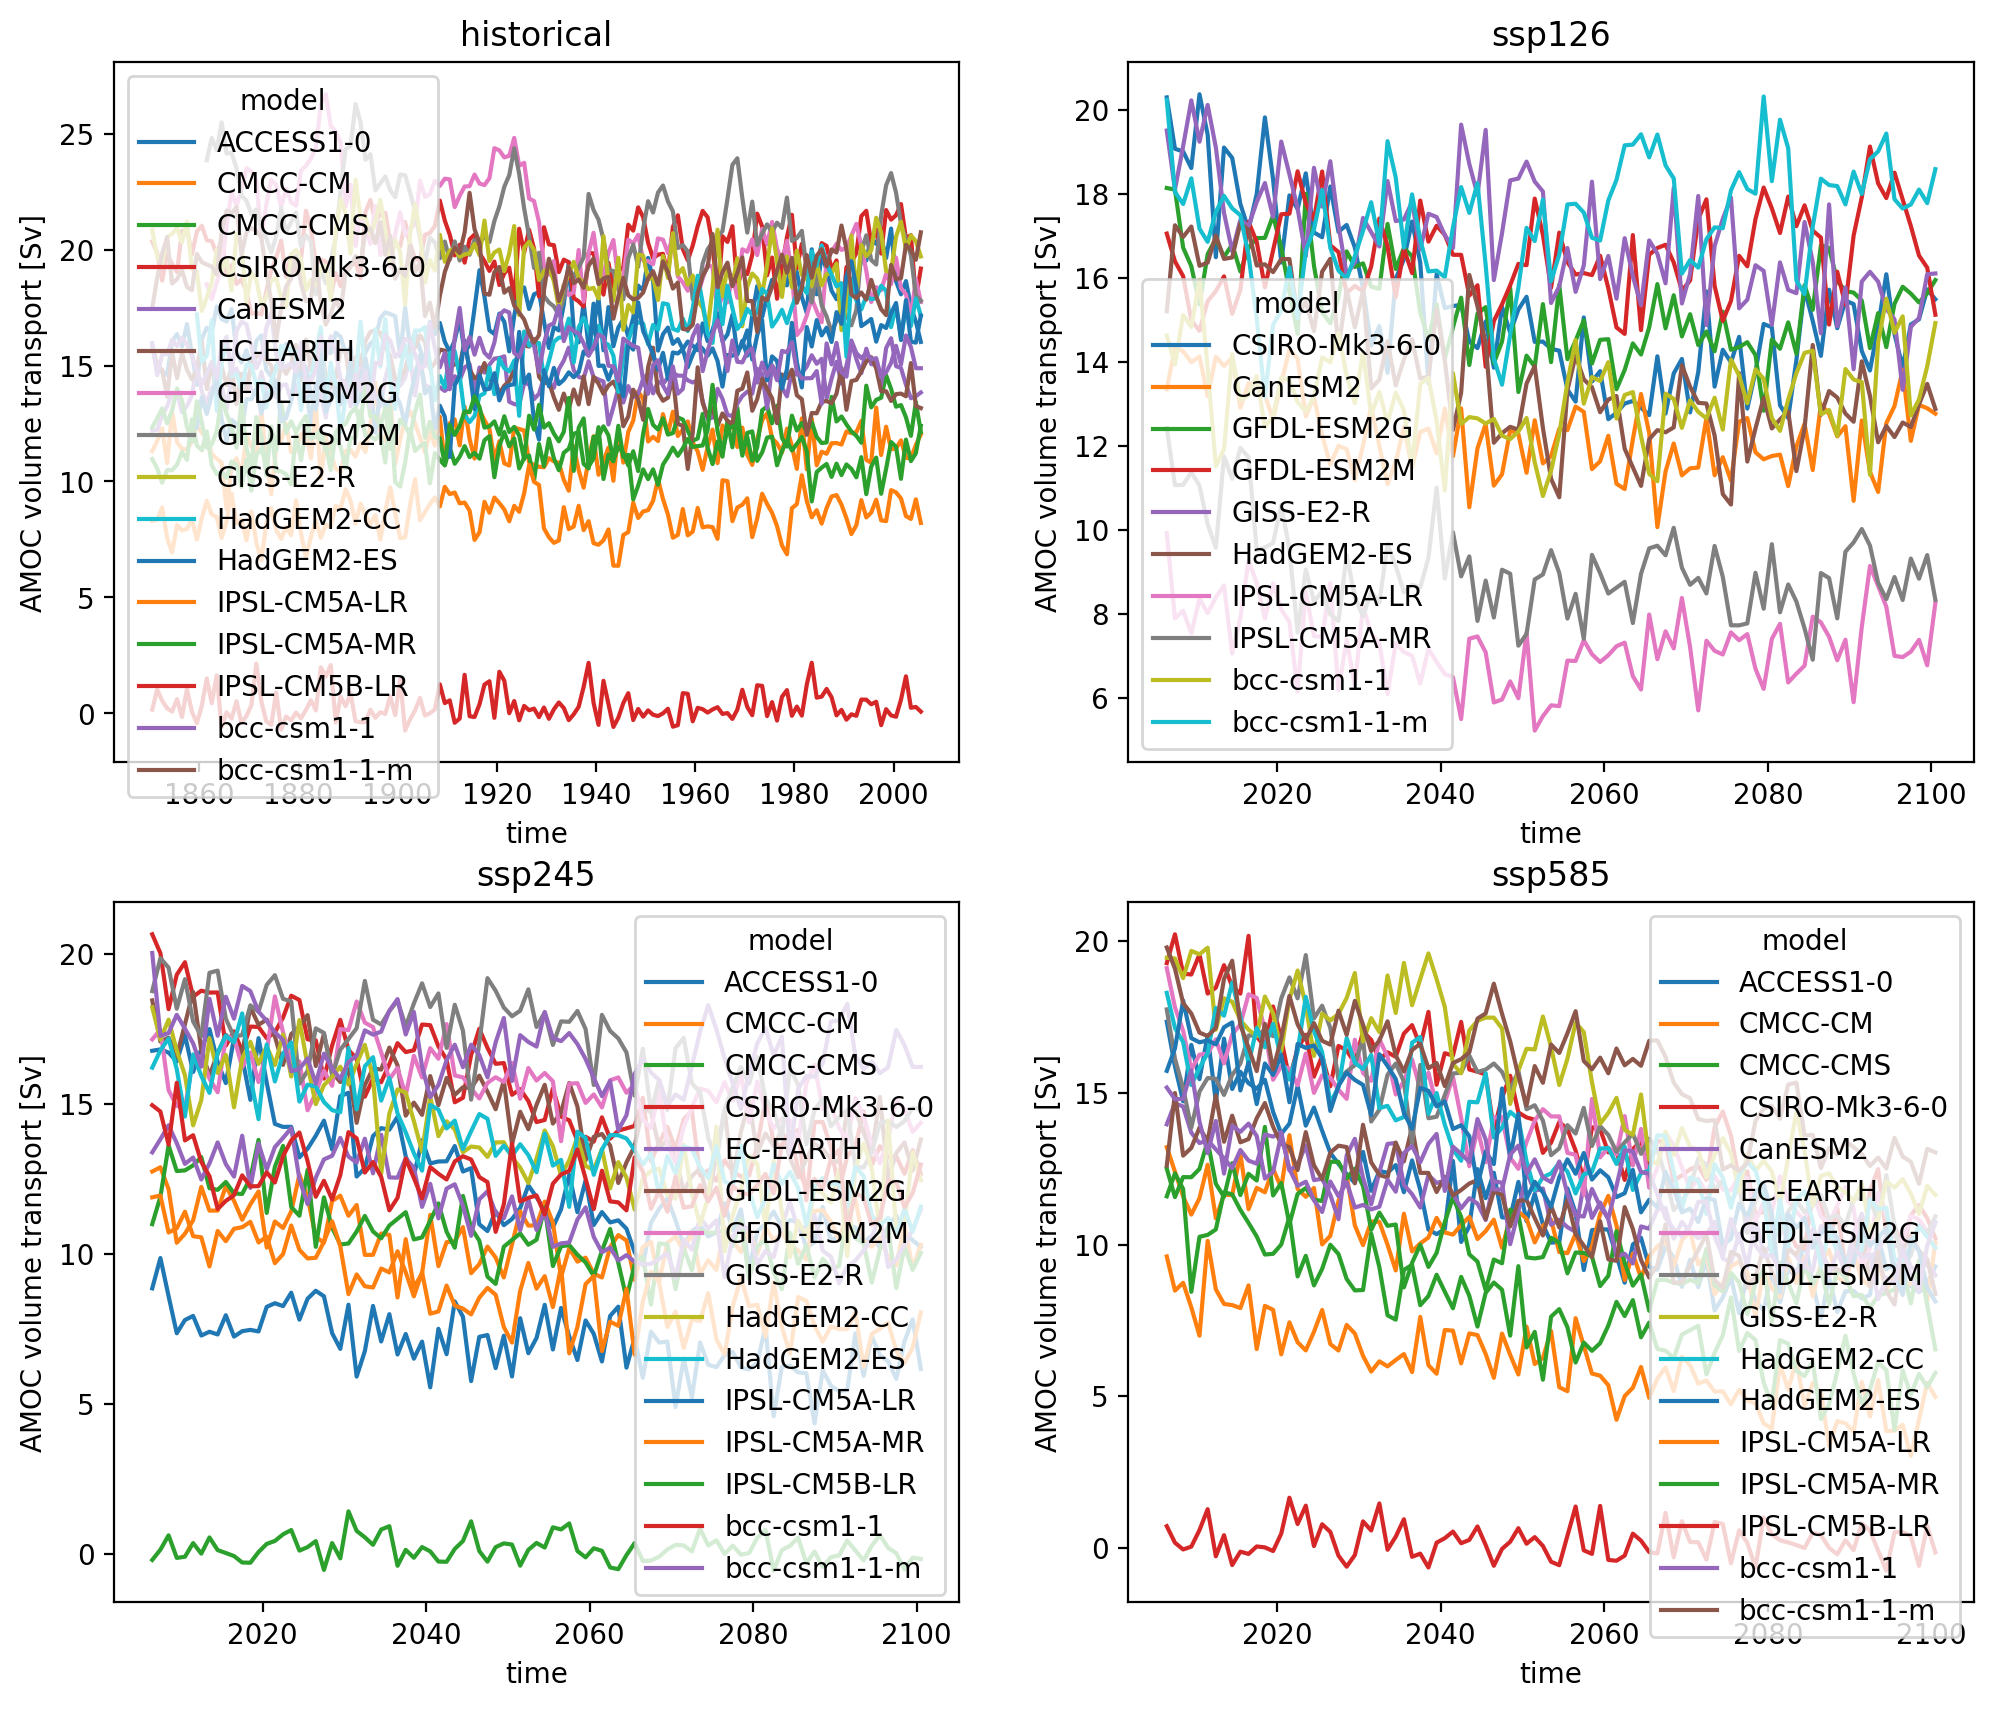

In [11]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,10))

cmip5_historical_ds.amoc.sel(latitude=lats).plot.line(x='time', ax=ax[0,0])
ax[0,0].set_title('historical')

cmip5_rcp26_ds.amoc.sel(latitude=lats).plot.line(x='time', ax=ax[0,1])
ax[0,1].set_title('ssp126')

cmip5_rcp45_ds.amoc.sel(latitude=lats).plot.line(x='time', ax=ax[1,0])
ax[1,0].set_title('ssp245')

cmip5_rcp85_ds.amoc.sel(latitude=lats).plot.line(x='time', ax=ax[1,1])
ax[1,1].set_title('ssp585')

### Check CMIP6 data

In [12]:
cmip6_historical_ds = xr.open_mfdataset('../outputs/cmip6_amoc_vo/*historical*.nc')
cmip6_ssp126_ds = xr.open_mfdataset('../outputs/cmip6_amoc_vo/*ssp126*.nc')
cmip6_ssp245_ds = xr.open_mfdataset('../outputs/cmip6_amoc_vo/*ssp245*.nc')
cmip6_ssp585_ds = xr.open_mfdataset('../outputs/cmip6_amoc_vo/*ssp585*.nc')

Text(0.5, 1.0, 'ssp585')

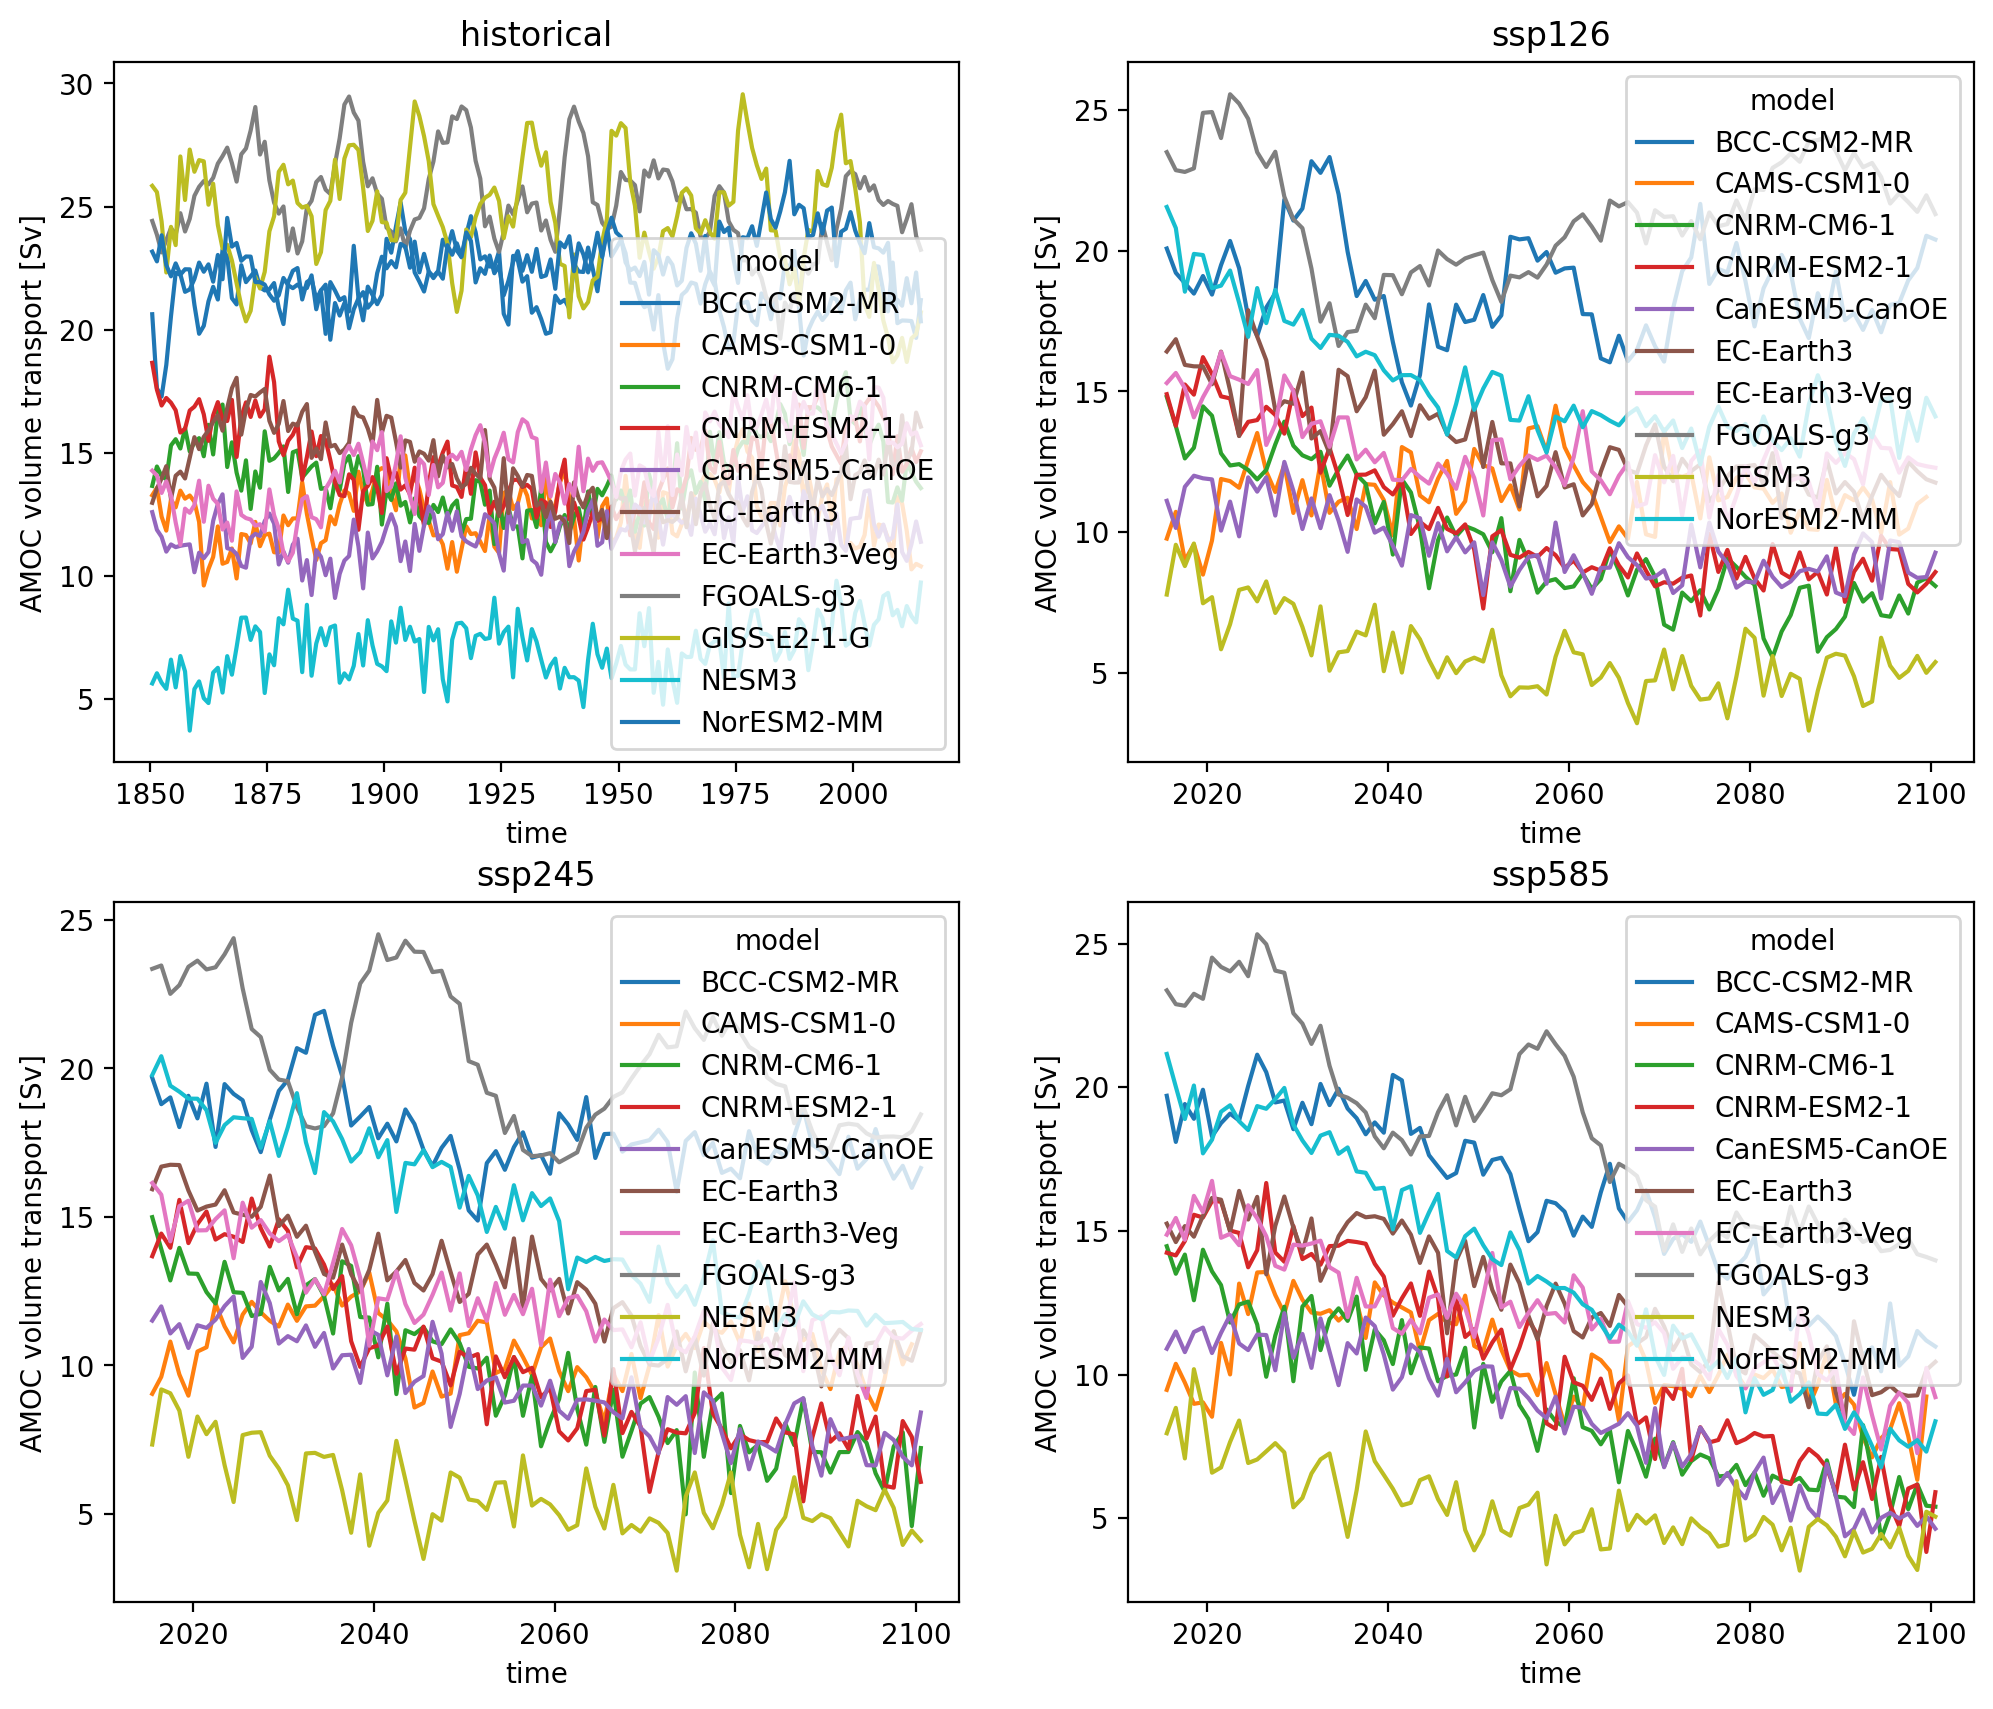

In [13]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,10))

cmip6_historical_ds.amoc.sel(latitude=lats).plot.line(x='time', ax=ax[0,0])
ax[0,0].set_title('historical')

cmip6_ssp126_ds.amoc.sel(latitude=lats).plot.line(x='time', ax=ax[0,1])
ax[0,1].set_title('ssp126')

cmip6_ssp245_ds.amoc.sel(latitude=lats).plot.line(x='time', ax=ax[1,0])
ax[1,0].set_title('ssp245')

cmip6_ssp585_ds.amoc.sel(latitude=lats).plot.line(x='time', ax=ax[1,1])
ax[1,1].set_title('ssp585')

#ax[0].legend(bbox_to_anchor=(1,1), loc="upper left")

In [14]:
model_intersection = list(set(cmip6_historical_ds.model.values) & 
                              set(cmip6_ssp245_ds.model.values))
model_intersection.sort()
amoc_vo_ssp245_ds = xr.concat([cmip6_historical_ds,cmip6_ssp245_ds],'time', join='outer').sel(model=model_intersection)

In [15]:
amoc_vo_ssp245_ds

<xarray.Dataset> Size: 43kB
Dimensions:   (model: 10, time: 251, latitude: 2)
Coordinates:
  * model     (model) <U13 520B 'BCC-CSM2-MR' 'CAMS-CSM1-0' ... 'NorESM2-MM'
  * time      (time) float64 2kB 1.85e+03 1.852e+03 ... 2.1e+03 2.1e+03
  * latitude  (latitude) int64 16B 26 35
Data variables:
    amoc      (model, time, latitude) float64 40kB dask.array<chunksize=(1, 165, 2), meta=np.ndarray>
Attributes:
    source_file:    This NetCDF file was built from Compute_amoc_from_vo.py
    creation_date:  2022-09-22 13:28

## Compare the results from different models and methods

In [ ]:
amoc_msftmz_diff = (amoc_ds.msftmz.sel(time=slice(2090.5,2099.5)).mean(dim='time') - 
                    amoc_ds.msftmz.sel(time=slice(1986.5,2005.5)).mean(dim='time'))

amoc_msftyz_diff = (amoc_y_ds.msftyz.sel(time=slice(2090.5,2099.5)).mean(dim='time') - 
                    amoc_y_ds.msftyz.sel(time=slice(1986.5,2005.5)).mean(dim='time'))

rho_0 = 1028 # kg/m3
amoc_msftmz_diff = amoc_msftmz_diff/rho_0/1e6
amoc_msftyz_diff = amoc_msftyz_diff/rho_0/1e6

amoc_vo_diff = (amoc_vo_ssp245_ds.amoc.sel(time=slice(2090.5,2099.5)).mean(dim='time') - 
                    amoc_vo_ssp245_ds.amoc.sel(time=slice(1986.5,2005.5)).mean(dim='time'))

df_m_table = pd.DataFrame(amoc_msftmz_diff, index=amoc_msftmz_diff.model)
df_y_table = pd.DataFrame(amoc_msftyz_diff, index=amoc_msftyz_diff.model)
df_v_table = pd.DataFrame(amoc_vo_diff, index=amoc_vo_diff.model)
print(df_m_table)

                       0
ACCESS-CM2     -6.713229
ACCESS-ESM1-5  -5.078333
CESM2-WACCM    -9.850371
CanESM5        -4.676149
INM-CM4-8      -3.919750
INM-CM5-0      -2.691125
MIROC6         -4.775643
MPI-ESM1-2-HR  -4.395921
MPI-ESM1-2-LR  -3.789514
MRI-ESM2-0     -9.705536
NorESM2-LM    -11.597001


In [23]:
amoc_diff_all = pd.concat([df_m_table, df_y_table])

print(amoc_diff_all)

                       0
ACCESS-CM2     -6.713229
ACCESS-ESM1-5  -5.078333
CESM2-WACCM    -9.850371
CanESM5        -4.676149
INM-CM4-8      -3.919750
INM-CM5-0      -2.691125
MIROC6         -4.775643
MPI-ESM1-2-HR  -4.395921
MPI-ESM1-2-LR  -3.789514
MRI-ESM2-0     -9.705536
NorESM2-LM    -11.597001
CMCC-CM2-SR5   -3.843251
CMCC-ESM2      -4.977151
GFDL-ESM4      -0.000416
IPSL-CM6A-LR   -4.879367
MRI-ESM2-0     -9.148557
